In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid")

print("All imports successful ✅")

All imports successful ✅


In [4]:
df = pd.read_csv('../data/ethiopia.csv')

df['Country'] = 'Ethiopia'

df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

df['Month'] = df['Date'].dt.month

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (4108, 15)

First 5 rows:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Data Loading & Date Parsing

The dataset contains daily climate observations for Ethiopia from NASA POWER.
YEAR and DOY columns have been combined into a proper datetime column.
A Month column has been extracted for seasonal analysis.

In [5]:
df.replace(-999, np.nan, inplace=True)

print("Sentinel values (-999) replaced with NaN ✅")
print("\nMissing values per column after replacement:")
print(df.isna().sum())

Sentinel values (-999) replaced with NaN ✅

Missing values per column after replacement:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {duplicate_count} duplicate rows.")
else:
    print("No duplicates found.")

print(f"\nDataset shape after deduplication: {df.shape}")

Number of duplicate rows: 0
No duplicates found.

Dataset shape after deduplication: (4108, 15)


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Summary Statistics Interpretation

Ethiopia's dataset contains 4,108 daily observations from January 2015 to
March 2026 with no missing values after sentinel replacement.

**Temperature:** The mean daily temperature is 16.1°C with a low standard
deviation of 1.9°C, indicating a stable, moderate climate typical of the
Ethiopian Highlands. The range of 10°C–21.5°C is notably cooler than
most sub-Saharan African countries.

**Daily temperature range:** The average daily swing of 13°C (max − min)
is large, reflecting highland characteristics — warm days and cold nights.
This is important for agriculture as crops experience significant thermal stress.

**Precipitation:** Highly right-skewed. The mean is 3.6 mm/day but most days
record near zero, with occasional extreme events reaching 82.3 mm. The large
standard deviation (6.3 mm) confirms high variability — consistent with
Ethiopia's bimodal rainy seasons (Belg: Mar–May, Kiremt: Jun–Sep).

**Pressure (PS):** Nearly constant across all rows (std = 0.099 kPa),
confirming a consistent high-altitude measurement station. This column
has minimal analytical value.

In [8]:
total_rows = len(df)

missing = df.isna().sum()
missing_pct = (missing / total_rows * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Value Report:")
print(missing_report[missing_report['Missing Count'] > 0])

print("\nColumns with >5% missing values:")
high_missing = missing_report[missing_report['Missing %'] > 5]
if len(high_missing) > 0:
    print(high_missing)
else:
    print("None — all columns are below the 5% threshold ✅")

Missing Value Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Columns with >5% missing values:
None — all columns are below the 5% threshold ✅


In [9]:
# Columns to check for outliers
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

outlier_report = {}

for col in outlier_cols:
    col_data = df[col].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    outlier_count = (z_scores > 3).sum()
    outlier_report[col] = outlier_count

outlier_df = pd.DataFrame.from_dict(
    outlier_report, orient='index', columns=['Outlier Count (|Z|>3)']
)

print("Outlier Report:")
print(outlier_df)
print(f"\nTotal outlier rows flagged: {outlier_df['Outlier Count (|Z|>3)'].sum()}")

Outlier Report:
             Outlier Count (|Z|>3)
T2M                              3
T2M_MAX                          0
T2M_MIN                         18
PRECTOTCORR                     95
RH2M                            13
WS2M                             3
WS2M_MAX                         5

Total outlier rows flagged: 137


In [10]:
# Strategy: Cap outliers at 3 standard deviations (Winsorization)
# This preserves data volume while limiting extreme influence

for col in outlier_cols:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped at ±3 standard deviations ✅")

# Forward fill remaining missing values for weather variables
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

df[weather_cols] = df[weather_cols].ffill()

# Drop rows where more than 30% of values are still missing
threshold = len(df.columns) * 0.3
df.dropna(thresh=int(threshold), inplace=True)

print(f"Missing values handled with forward-fill ✅")
print(f"Final dataset shape: {df.shape}")

Outliers capped at ±3 standard deviations ✅
Missing values handled with forward-fill ✅
Final dataset shape: (4108, 15)


## Outlier & Missing Value Decisions

**Outliers:** We chose to cap (Winsorize) rather than drop outliers.
Climate data can contain genuine extreme events, so dropping them would
lose real signal. Capping at ±3 std limits distortion while retaining the rows.

**Missing values:** Forward-fill is appropriate for daily weather time series
because climate conditions change gradually — the previous day's value is
a reasonable estimate for a missing observation.

In [11]:
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data exported to data/ethiopia_clean.csv ✅")
print(f"Final shape: {df.shape}")

Cleaned data exported to data/ethiopia_clean.csv ✅
Final shape: (4108, 15)


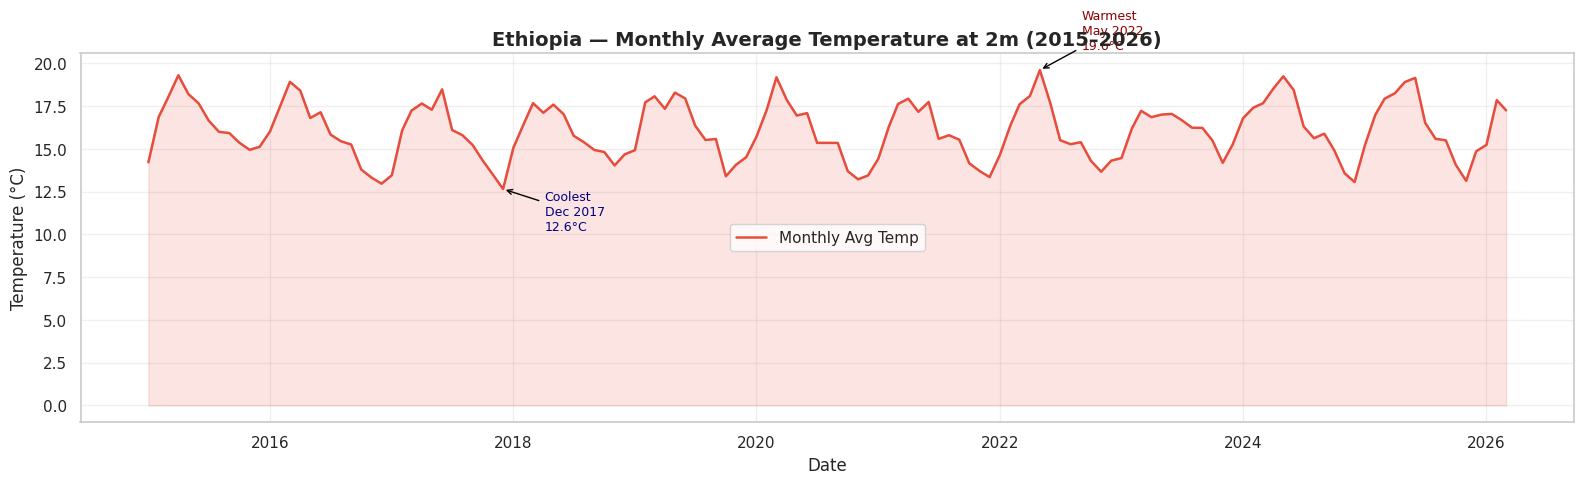

Chart saved ✅


In [12]:
# Compute monthly average temperature
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()

# Find warmest and coolest months
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(monthly_temp.index, monthly_temp.values, color='#e74c3c', linewidth=1.8, label='Monthly Avg Temp')
ax.fill_between(monthly_temp.index, monthly_temp.values, alpha=0.15, color='#e74c3c')

# Annotate warmest
ax.annotate(f'Warmest\n{warmest.strftime("%b %Y")}\n{monthly_temp[warmest]:.1f}°C',
            xy=(warmest, monthly_temp[warmest]),
            xytext=(30, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='darkred')

# Annotate coolest
ax.annotate(f'Coolest\n{coolest.strftime("%b %Y")}\n{monthly_temp[coolest]:.1f}°C',
            xy=(coolest, monthly_temp[coolest]),
            xytext=(30, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='navy')

ax.set_title('Ethiopia — Monthly Average Temperature at 2m (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_temp_timeseries.png', dpi=150)
plt.show()
print("Chart saved ✅")

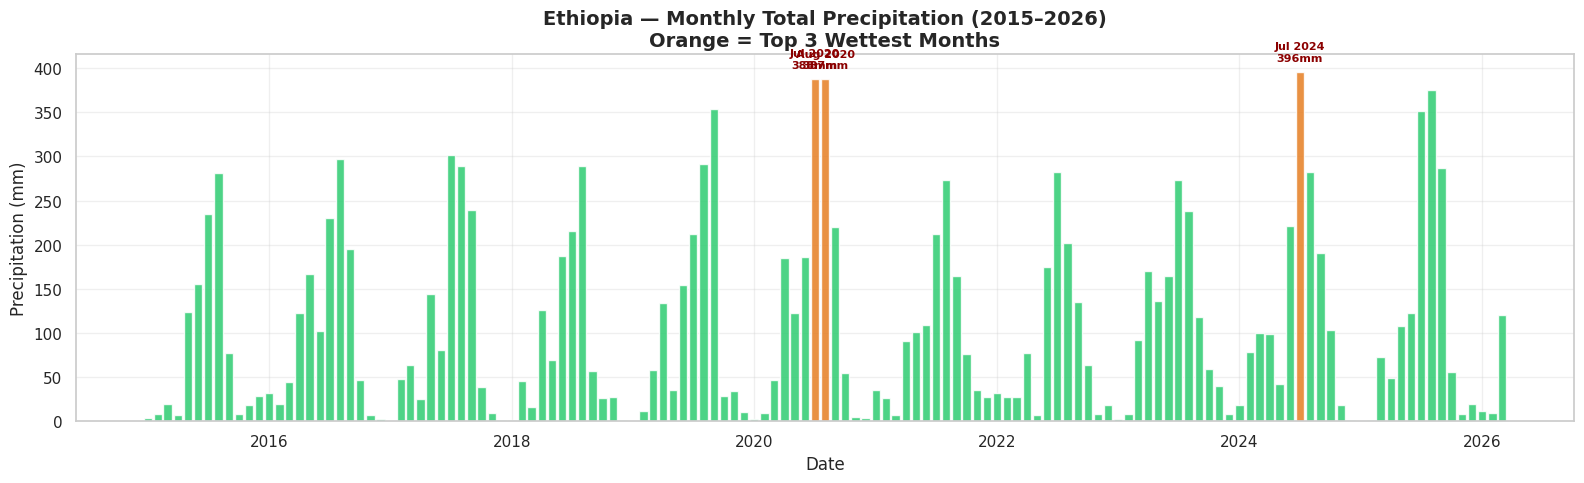

In [13]:
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

# Find peak months
top3_months = monthly_precip.nlargest(3)

fig, ax = plt.subplots(figsize=(16, 5))

colors = ['#2ecc71' if m not in top3_months.index else '#e67e22'
          for m in monthly_precip.index]

ax.bar(monthly_precip.index, monthly_precip.values,
       width=25, color=colors, alpha=0.85)

for month, val in top3_months.items():
    ax.annotate(f'{month.strftime("%b %Y")}\n{val:.0f}mm',
                xy=(month, val),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='darkred', fontweight='bold')

ax.set_title('Ethiopia — Monthly Total Precipitation (2015–2026)\nOrange = Top 3 Wettest Months', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_bar.png', dpi=150)
plt.show()

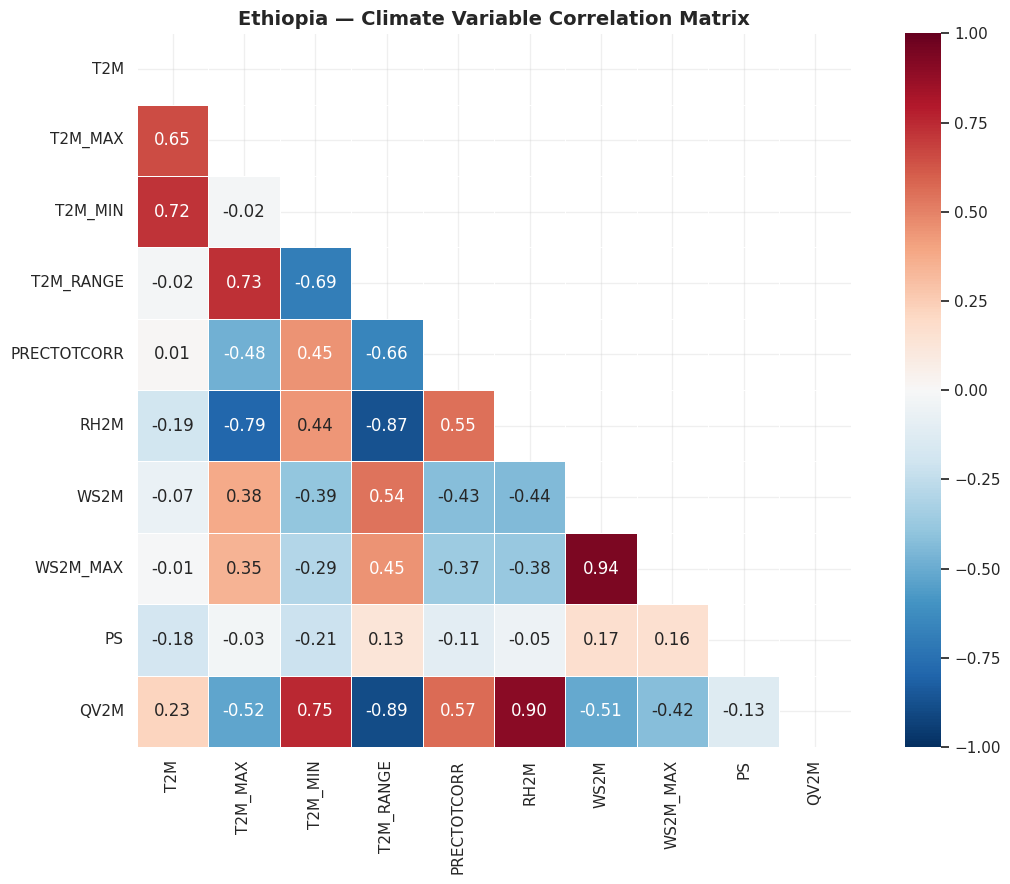

In [14]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
                'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)

ax.set_title('Ethiopia — Climate Variable Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_correlation_heatmap.png', dpi=150)
plt.show()

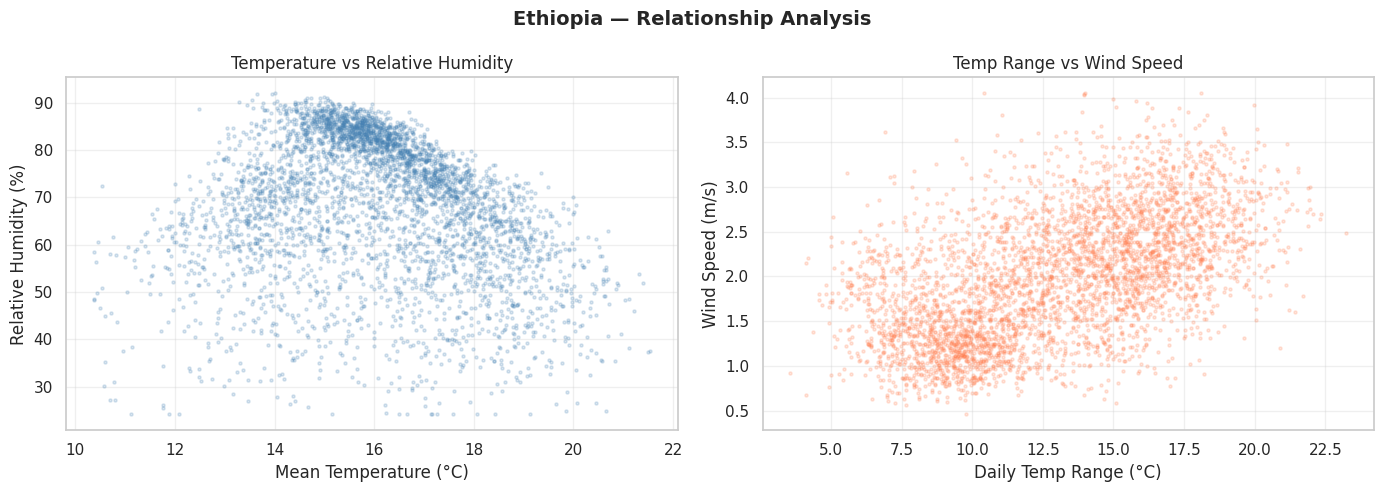

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Relative Humidity')

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.2, s=5, color='coral')
axes[1].set_xlabel('Daily Temp Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temp Range vs Wind Speed')

plt.suptitle('Ethiopia — Relationship Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_scatter_plots.png', dpi=150)
plt.show()

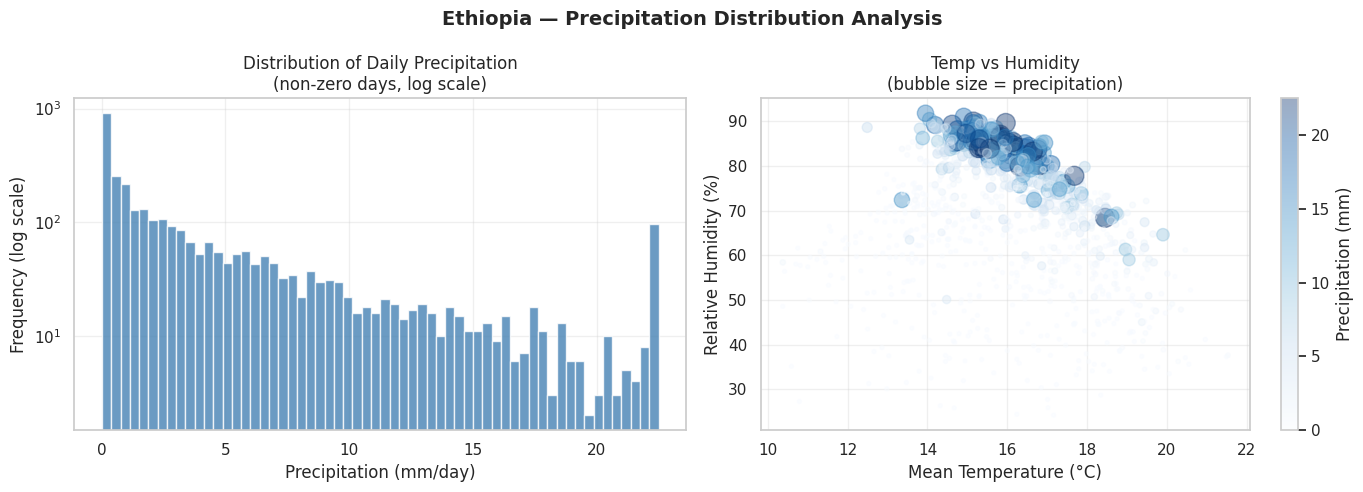

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale
precip_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
axes[0].hist(precip_nonzero, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Distribution of Daily Precipitation\n(non-zero days, log scale)')

# Bubble chart: T2M vs RH2M, size = PRECTOTCORR
sample = df.sample(min(1000, len(df)), random_state=42)
bubble_size = (sample['PRECTOTCORR'] + 1) * 8

scatter = axes[1].scatter(sample['T2M'], sample['RH2M'],
                           s=bubble_size, alpha=0.4,
                           c=sample['PRECTOTCORR'], cmap='Blues')
axes[1].set_xlabel('Mean Temperature (°C)')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title('Temp vs Humidity\n(bubble size = precipitation)')
plt.colorbar(scatter, ax=axes[1], label='Precipitation (mm)')

plt.suptitle('Ethiopia — Precipitation Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/ethiopia_precip_distribution.png', dpi=150)
plt.show()